# CNN training workflow for rooftop material classification

This notebook trains an ensemble of convolutional neural networks (CNNs) for multi-class rooftop material classification from 64 × 64 RGB image patches.

The reusable functions are stored in the `src/` package so that the notebook remains focused on the experimental workflow. Before running the notebook, edit `src/config.py` so that the input and output paths match your local environment.

## 1. Imports and runtime setup

In [1]:
import sys
import time
from pathlib import Path

# Allow imports from the repository root when the notebook is run from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np

from src import config_weighted_loss as cfg
from src.data import (
    augment_with_mirror_symmetries,
    create_train_test_split,
    list_channel_files,
    load_dataset,
    one_hot_encode_labels,
)
from src.evaluation import (
    compute_brier_scores,
    evaluate_predictions,
    plot_roc_curves,
)
from src.losses import compute_balanced_class_weights, weighted_categorical_crossentropy
from src.preprocessing import rotate_anisotropic_patches
from src.training import average_ensemble_probabilities, save_models, train_ensemble
from src.transfer_learning import train_mobilenetv2_baseline
from src.utils import prepare_output_directories, set_random_seed

start_time = time.perf_counter()
set_random_seed(cfg.RANDOM_SEED)
prepare_output_directories(
    cfg.OUTPUT_DIR,
    cfg.FIGURES_DIR,
    cfg.MODELS_DIR,
    cfg.MOBILENETV2_MODELS_DIR,
)


## 2. Configuration check

In [2]:
files_red_train, files_green_train, files_blue_train = list_channel_files(
    cfg.RED_PATTERN,
    cfg.GREEN_PATTERN,
    cfg.BLUE_PATTERN,
)

print(f"Output directory: {cfg.OUTPUT_DIR}")
print(f"Red patches: {len(files_red_train)}")
print(f"Green patches: {len(files_green_train)}")
print(f"Blue patches: {len(files_blue_train)}")

Output directory: X:\Projets\CASMATTELEv2\Stage_Hugo\py\classification\DL\DL_3_github
Red patches: 1601
Green patches: 1601
Blue patches: 1601


## 3. Data loading and optional CLAHE pre-processing

The image patches are loaded, filtered according to median brightness and normalised. CLAHE can be enabled or disabled using `USE_CLAHE` in `src/config.py`.

In [3]:
X, y, patch_ids = load_dataset(
    files_blue=files_blue_train,
    files_green=files_green_train,
    files_red=files_red_train,
    labels=cfg.LABELS,
    max_reflectance=cfg.MAX_REFLECTANCE,
    brightness_min=cfg.BRIGHTNESS_MIN,
    brightness_max=cfg.BRIGHTNESS_MAX,
    apply_clahe=cfg.USE_CLAHE,
)

print(f"CLAHE enabled: {cfg.USE_CLAHE}")
print(f"Input tensor: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Retained patches: {len(patch_ids)}")

CLAHE enabled: False
Input tensor: (1566, 64, 64, 3)
Labels: (1566,)
Retained patches: 1566


## 4. Optional HOG-based rotation of anisotropic patches

This step estimates the dominant texture orientation using Histogram of Oriented Gradients (HOG). It can be enabled or disabled using `USE_HOG` in `src/config.py`.

In [4]:
if cfg.USE_HOG:
    X = rotate_anisotropic_patches(
        x_values=X,
        n_channels=cfg.N_CHANNELS,
        hog_orientations=cfg.HOG_ORIENTATIONS,
        hog_min_threshold=cfg.HOG_MIN_THRESHOLD,
        hog_max_threshold=cfg.HOG_MAX_THRESHOLD,
        hog_accumulation_threshold=cfg.HOG_ACCUMULATION_THRESHOLD,
    )
    print("HOG-based rotation enabled.")
else:
    print("HOG-based rotation disabled.")

HOG-based rotation disabled.


## 5. Training/test split

The dataset is split before any data augmentation is applied. This prevents augmented versions of the same patch from being distributed across both the training and test subsets.

In [5]:
X_train, X_test, y_train_raw, y_test_raw = create_train_test_split(
    x_values=X,
    y_values=y,
    test_size=cfg.TEST_SIZE,
    random_seed=cfg.RANDOM_SEED,
)

print(f"Training samples before augmentation: {X_train.shape}")
print(f"Test samples: {X_test.shape}")

Training samples before augmentation: (1252, 64, 64, 3)
Test samples: (314, 64, 64, 3)


## 6. Optional data augmentation

Mirror-based data augmentation is applied to the training set only. This step can be disabled by setting `USE_DATA_AUGMENTATION = False` in `src/config.py`.

In [6]:
if cfg.USE_DATA_AUGMENTATION:
    X_train, y_train_raw = augment_with_mirror_symmetries(X_train, y_train_raw)
    print("Data augmentation enabled.")
else:
    print("Data augmentation disabled.")

y_train, y_test = one_hot_encode_labels(
    y_train_raw=y_train_raw,
    y_test_raw=y_test_raw,
    n_classes=cfg.N_CLASSES,
)

print(f"Training samples used for model fitting: {X_train.shape}")
print(f"Test samples used for evaluation: {X_test.shape}")

Data augmentation disabled.
Training samples used for model fitting: (1252, 64, 64, 3)
Test samples used for evaluation: (314, 64, 64, 3)


## 7. Optional weighted categorical cross-entropy

Class weights are computed from the training labels only. This provides a reviewer-requested test of whether explicitly weighting under-represented classes improves class-level performance. The test set remains unchanged and is not used to compute the weights.

In [7]:
if cfg.USE_WEIGHTED_CATEGORICAL_CROSSENTROPY:
    class_weights = compute_balanced_class_weights(
        y_train_raw=y_train_raw,
        n_classes=cfg.N_CLASSES,
    )
    training_loss = weighted_categorical_crossentropy(class_weights)
    print("Weighted categorical cross-entropy enabled.")
else:
    class_weights = None
    training_loss = "categorical_crossentropy"
    print("Standard categorical cross-entropy enabled.")

Class weights used for weighted categorical cross-entropy:
  class 0: 0.9315
  class 1: 0.9399
  class 2: 0.9315
  class 3: 0.9399
  class 4: 0.9315
  class 5: 1.0433
  class 6: 0.8842
  class 7: 0.9572
  class 8: 0.9399
  class 9: 0.9315
  class 10: 2.7456
  class 11: 0.9843
Weighted categorical cross-entropy enabled.


## 8. CNN ensemble training


Training model 1
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6

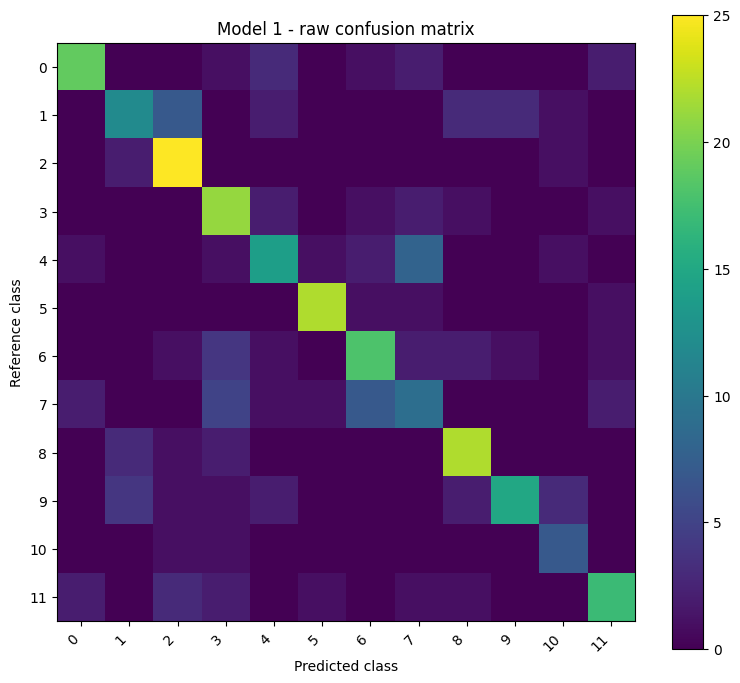

Class-wise precision: [0.79166667 0.57142857 0.64102564 0.55263158 0.56       0.88
 0.6        0.36       0.70967742 0.78947368 0.53846154 0.70833333]


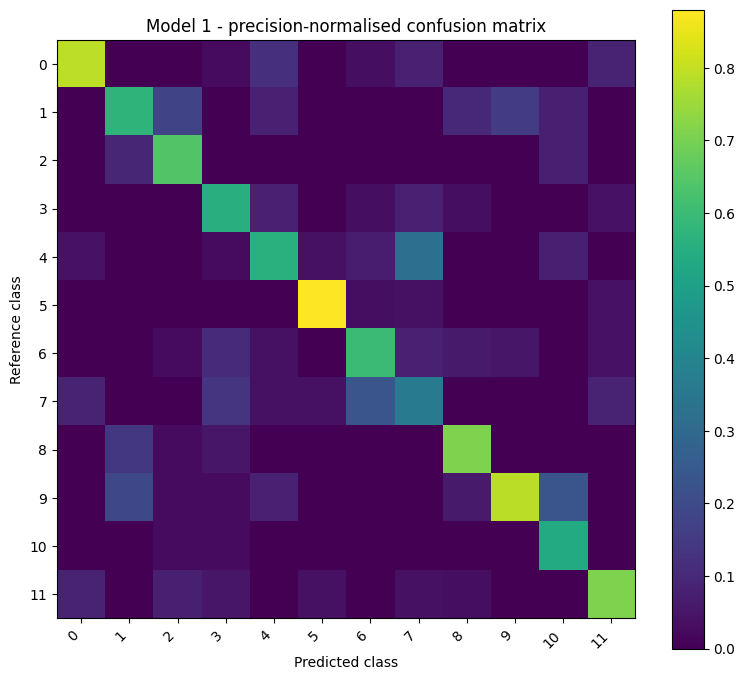

Class-wise recall: [0.67857143 0.42857143 0.89285714 0.75       0.5        0.88
 0.6        0.33333333 0.78571429 0.53571429 0.77777778 0.62962963]


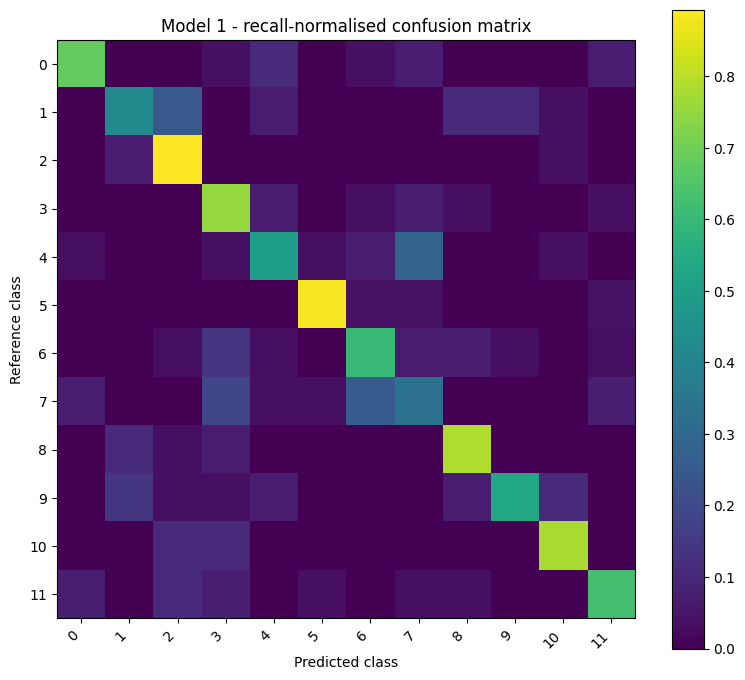

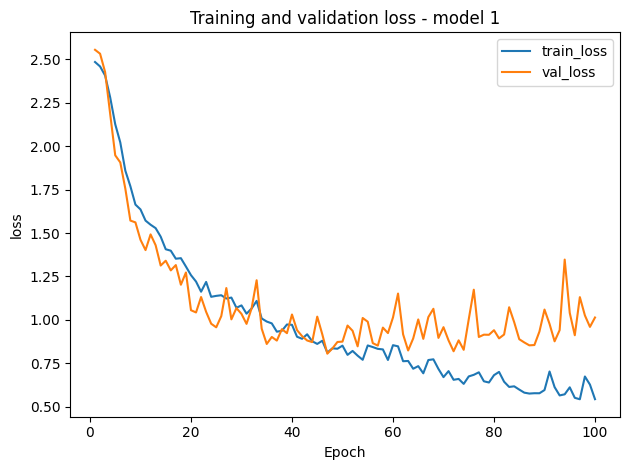


Training model 2
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 31, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_6 (MaxPooling  (None,

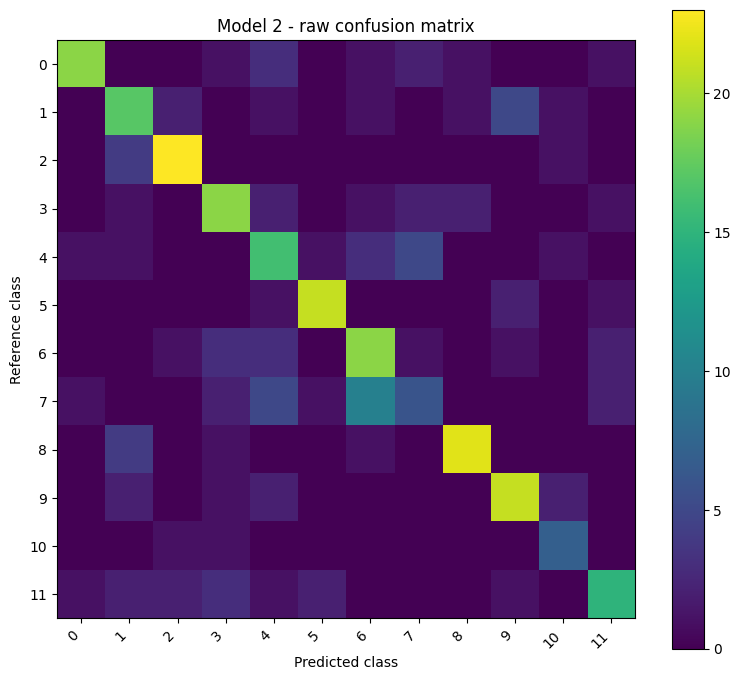

Class-wise precision: [0.86363636 0.5483871  0.79310345 0.61290323 0.47058824 0.84
 0.52777778 0.375      0.84615385 0.7        0.58333333 0.68181818]


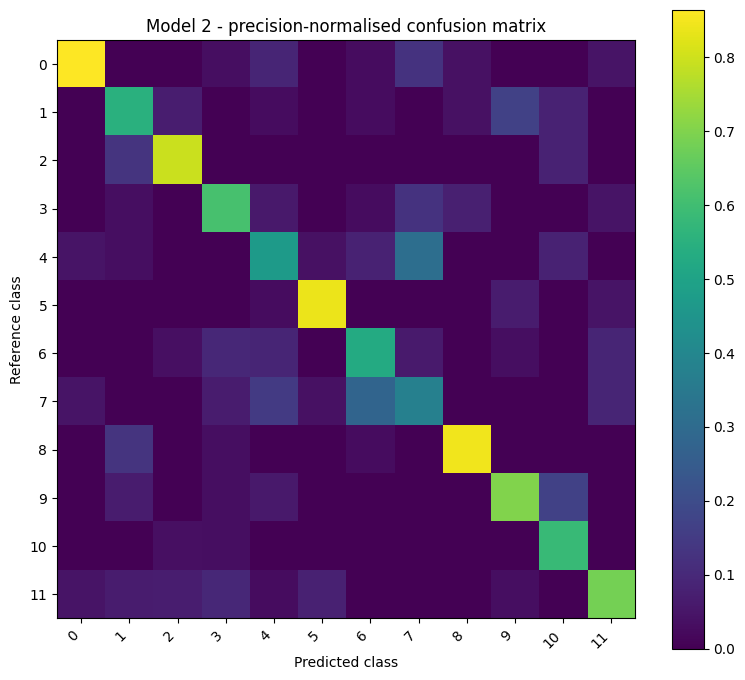

Class-wise recall: [0.67857143 0.60714286 0.82142857 0.67857143 0.57142857 0.84
 0.63333333 0.22222222 0.78571429 0.75       0.77777778 0.55555556]


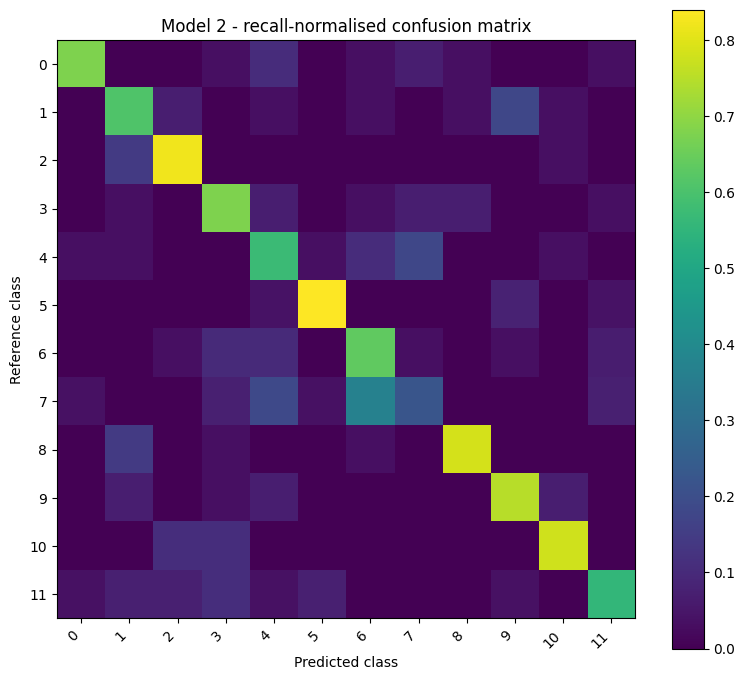

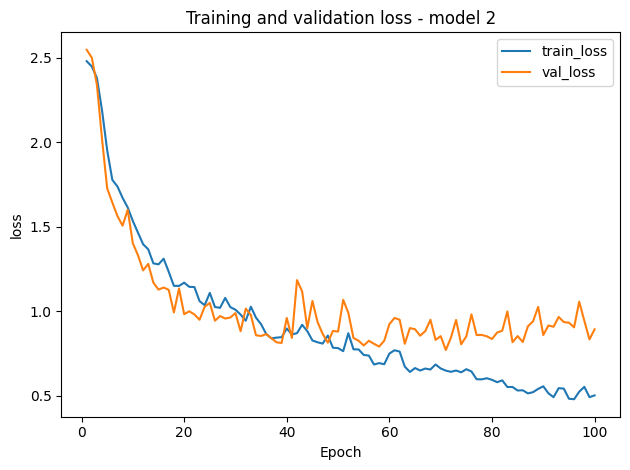


Training model 3
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 31, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None,

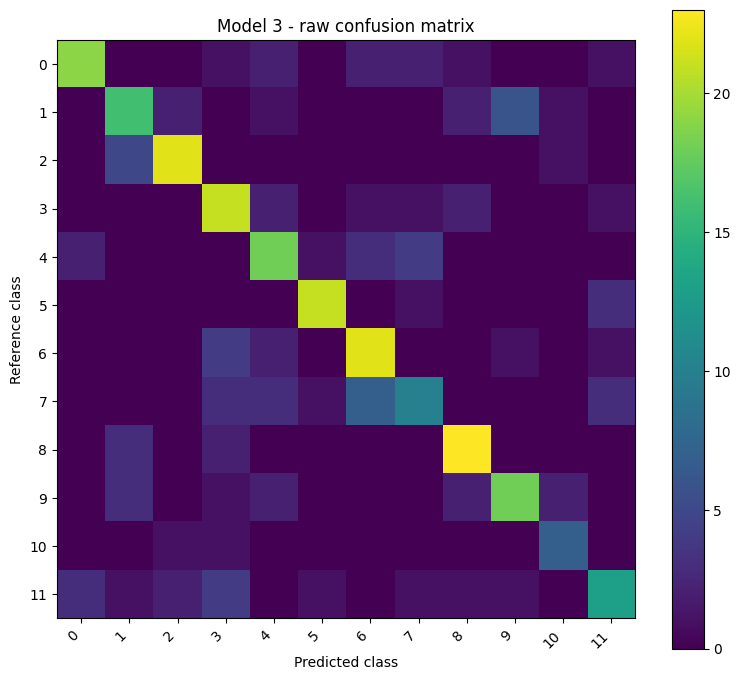

Class-wise precision: [0.79166667 0.57142857 0.81481481 0.56756757 0.6        0.875
 0.62857143 0.52631579 0.74193548 0.69230769 0.63636364 0.59090909]


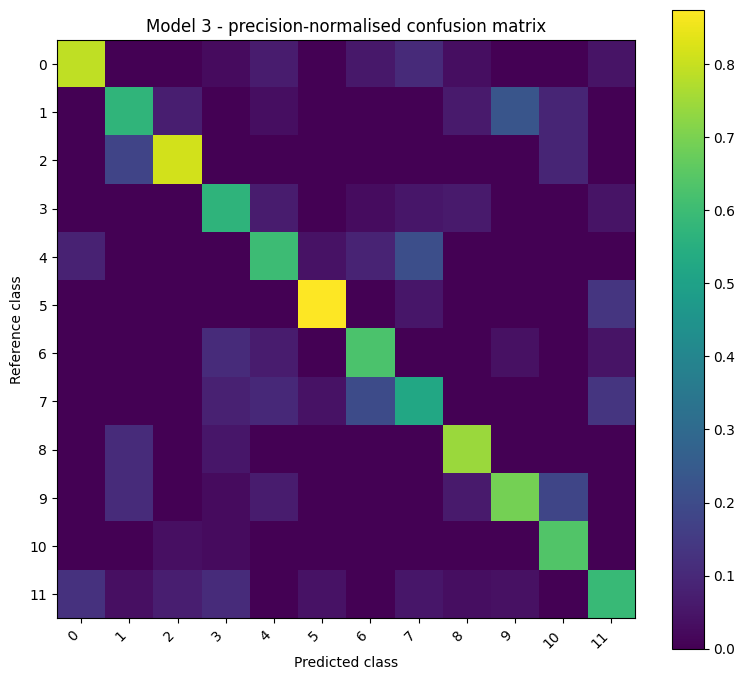

Class-wise recall: [0.67857143 0.57142857 0.78571429 0.75       0.64285714 0.84
 0.73333333 0.37037037 0.82142857 0.64285714 0.77777778 0.48148148]


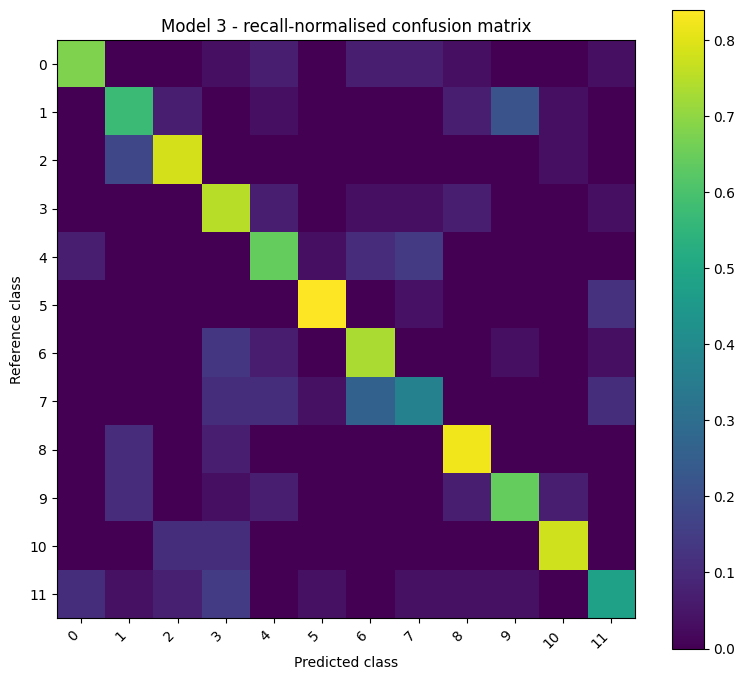

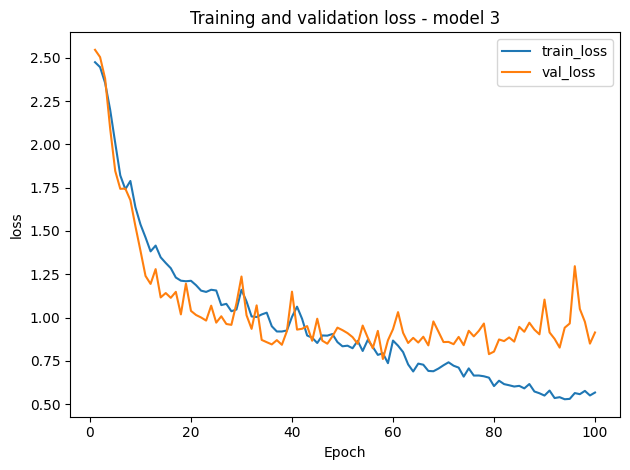


Training model 4
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_14 (MaxPoolin  (None,

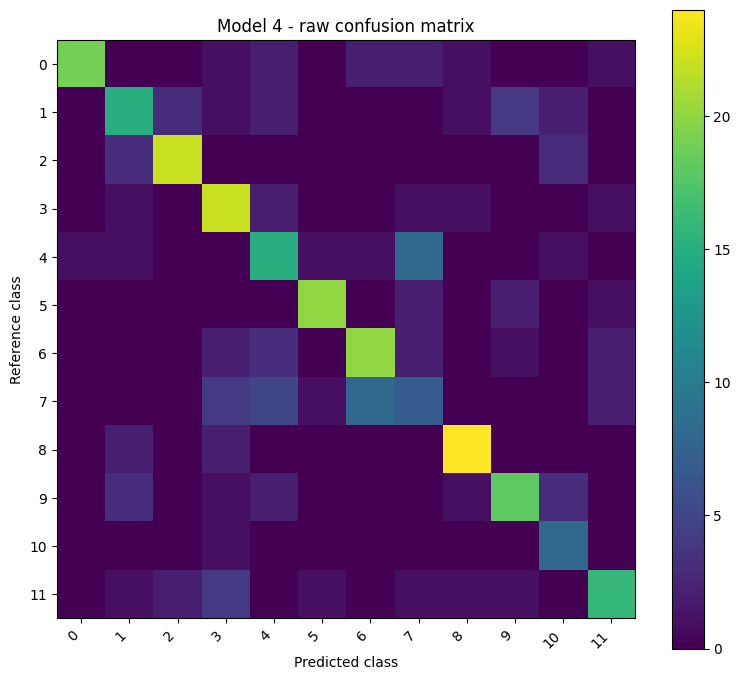

Class-wise precision: [0.95       0.57692308 0.81481481 0.57894737 0.48387097 0.86956522
 0.64516129 0.30434783 0.82758621 0.69230769 0.47058824 0.69565217]


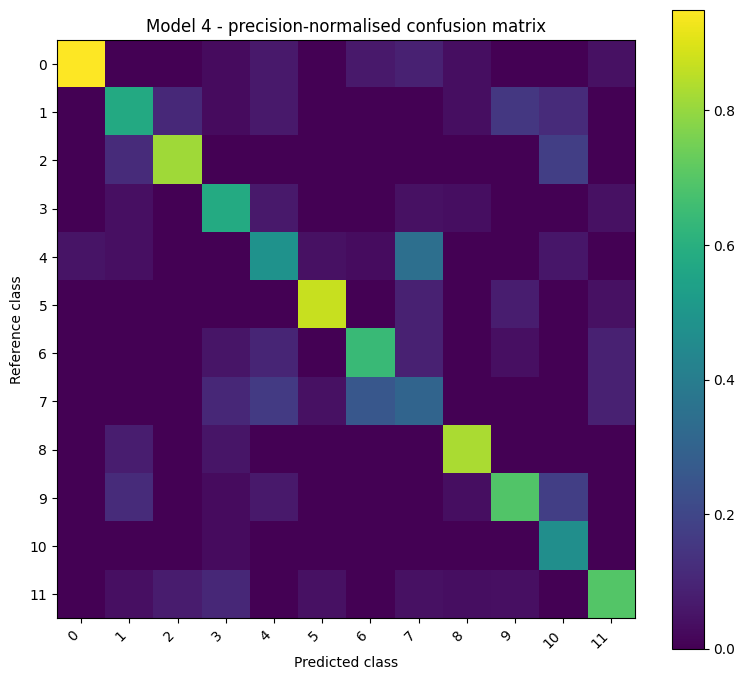

Class-wise recall: [0.67857143 0.53571429 0.78571429 0.78571429 0.53571429 0.8
 0.66666667 0.25925926 0.85714286 0.64285714 0.88888889 0.59259259]


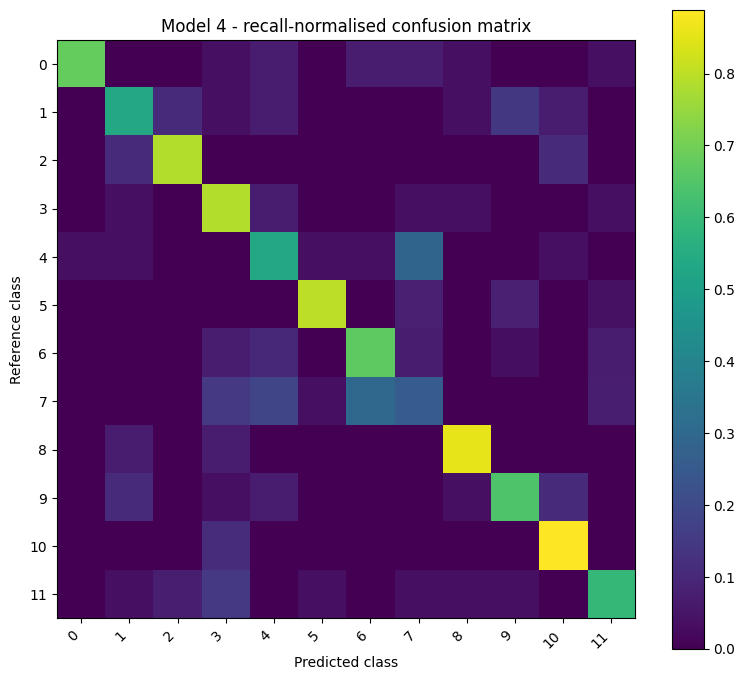

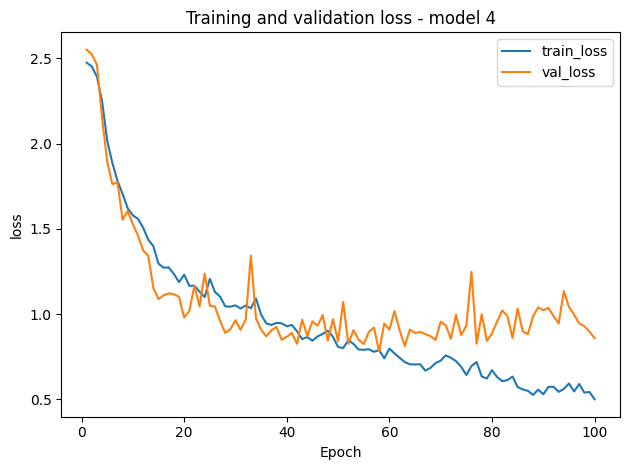


Training model 5
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_17 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_17 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_18 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_18 (MaxPoolin  (None,

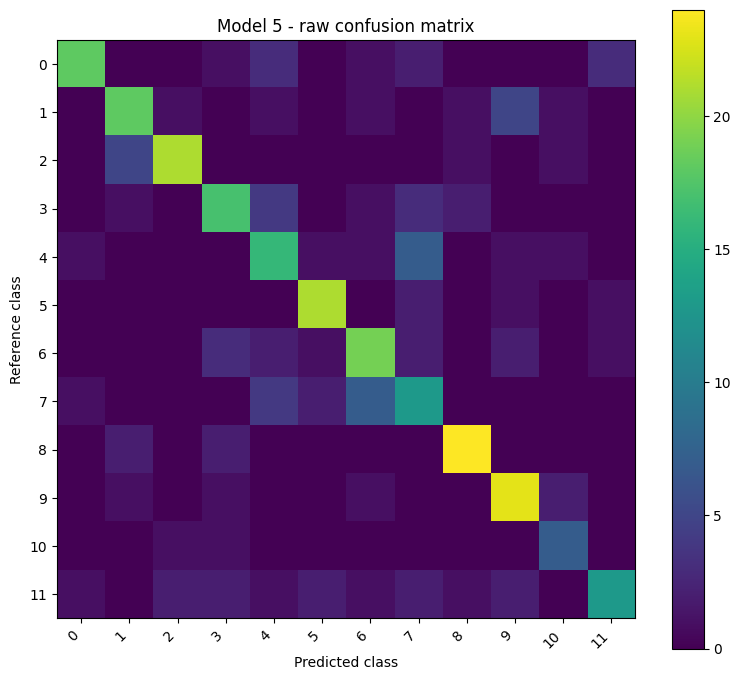

Class-wise precision: [0.85714286 0.66666667 0.84       0.62962963 0.51612903 0.77777778
 0.59375    0.41935484 0.82758621 0.67647059 0.58333333 0.72222222]


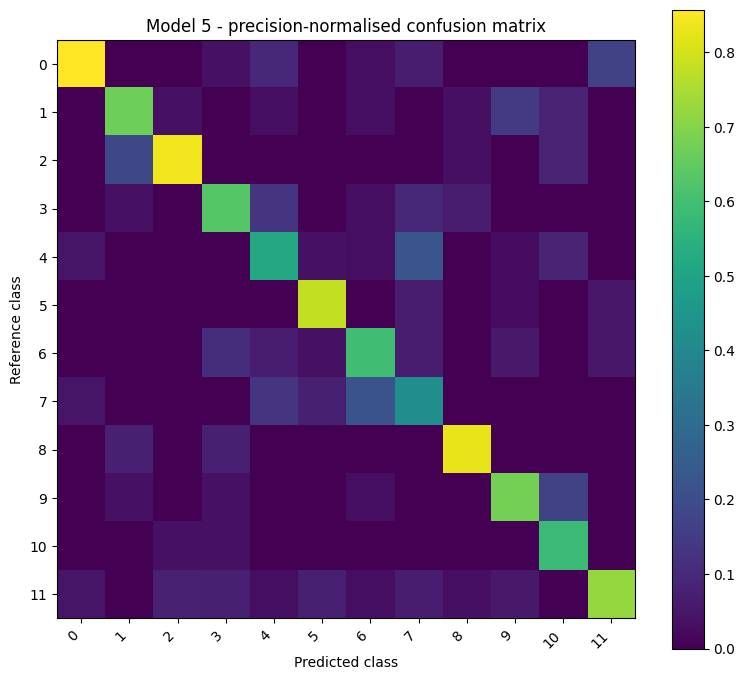

Class-wise recall: [0.64285714 0.64285714 0.75       0.60714286 0.57142857 0.84
 0.63333333 0.48148148 0.85714286 0.82142857 0.77777778 0.48148148]


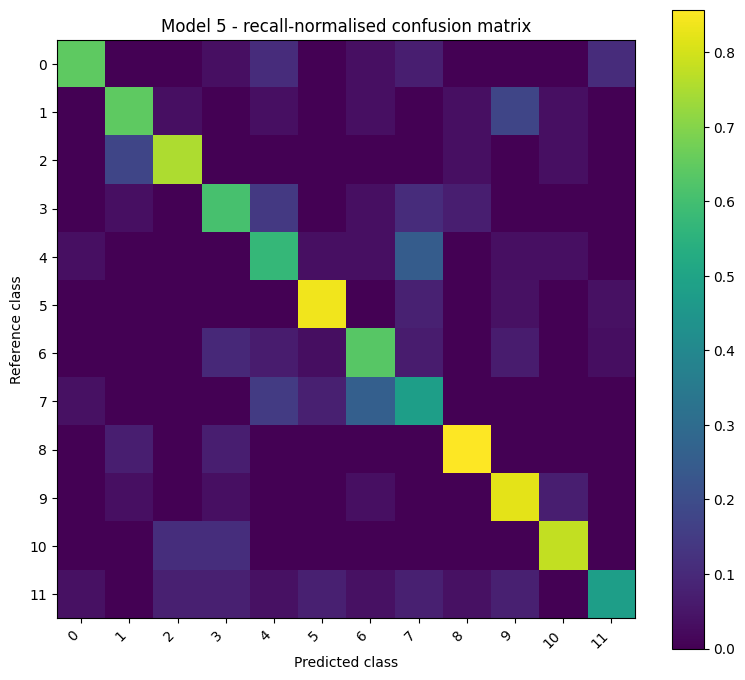

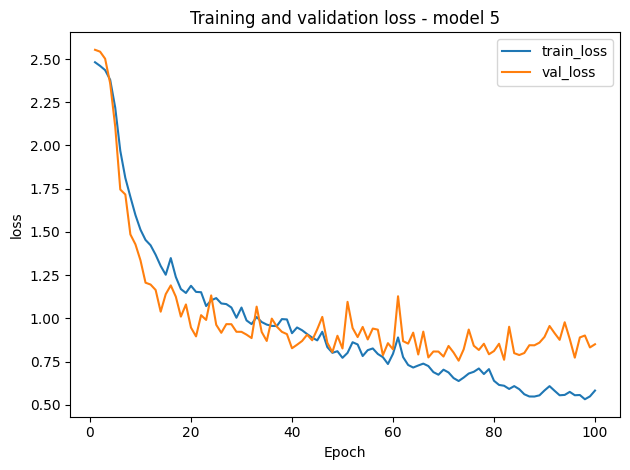


Training model 6
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_21 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_22 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_22 (MaxPoolin  (None,

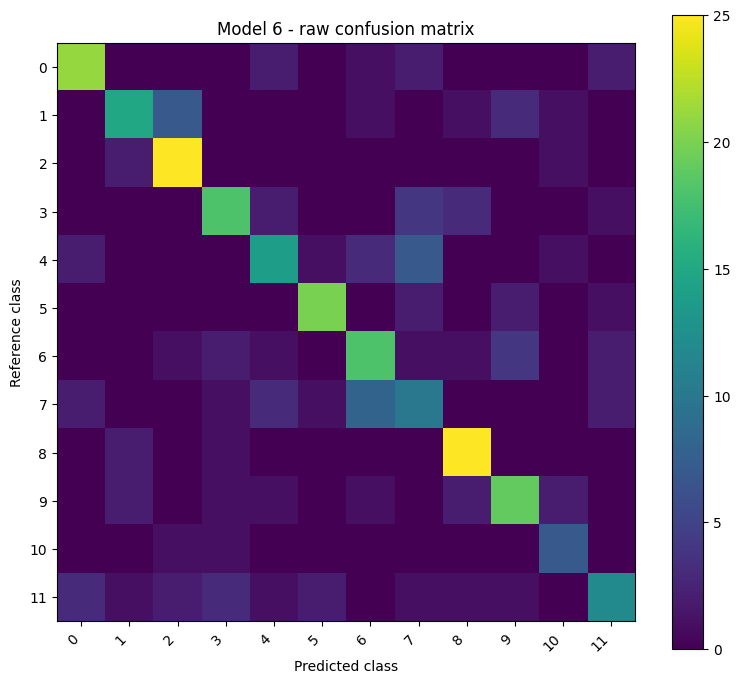

Class-wise precision: [0.75       0.68181818 0.69444444 0.66666667 0.58333333 0.83333333
 0.5625     0.37037037 0.75757576 0.65517241 0.58333333 0.6       ]


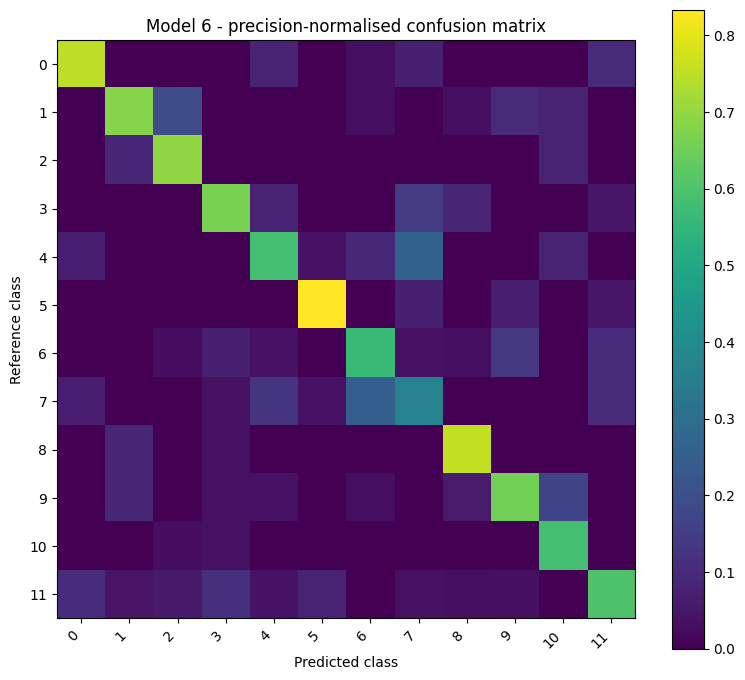

Class-wise recall: [0.75       0.53571429 0.89285714 0.64285714 0.5        0.8
 0.6        0.37037037 0.89285714 0.67857143 0.77777778 0.44444444]


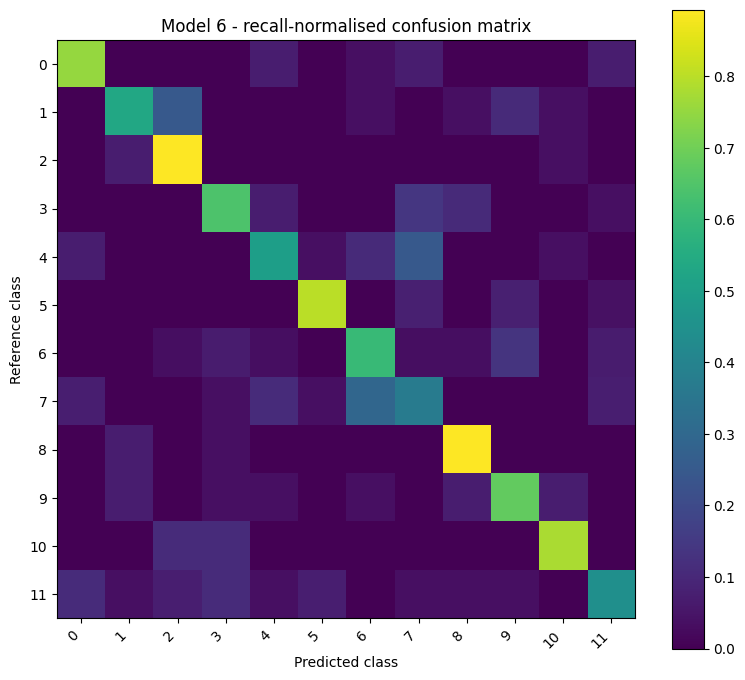

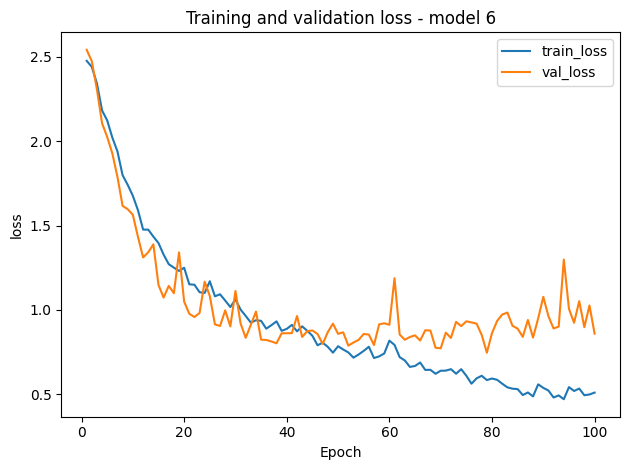


Training model 7
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_24 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_25 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_25 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_26 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_26 (MaxPoolin  (None,

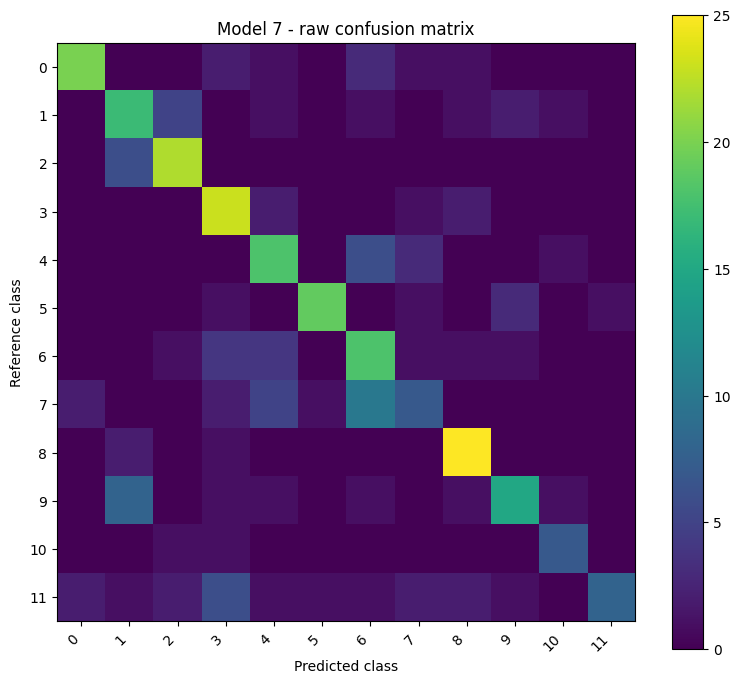

Class-wise precision: [0.83333333 0.5        0.70967742 0.56097561 0.54545455 0.9047619
 0.45       0.4375     0.75757576 0.68181818 0.7        0.88888889]


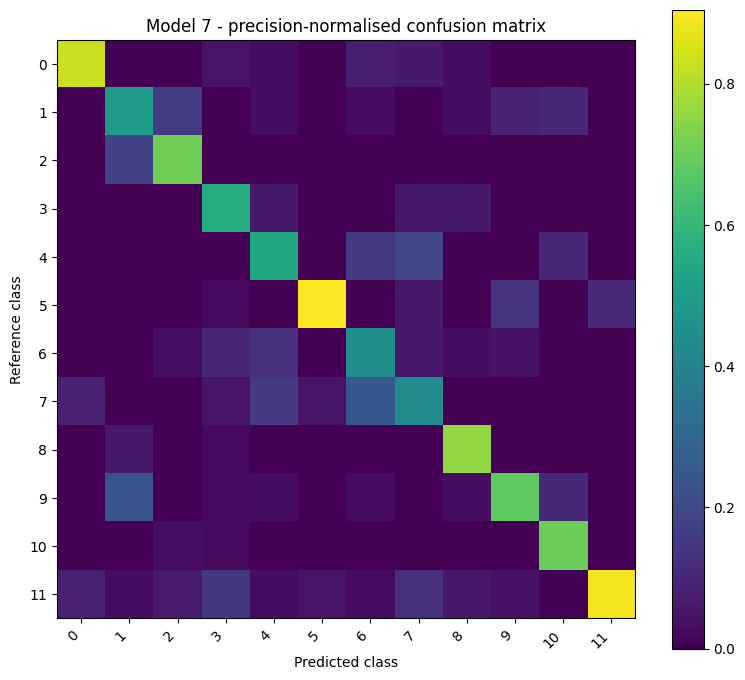

Class-wise recall: [0.71428571 0.60714286 0.78571429 0.82142857 0.64285714 0.76
 0.6        0.25925926 0.89285714 0.53571429 0.77777778 0.2962963 ]


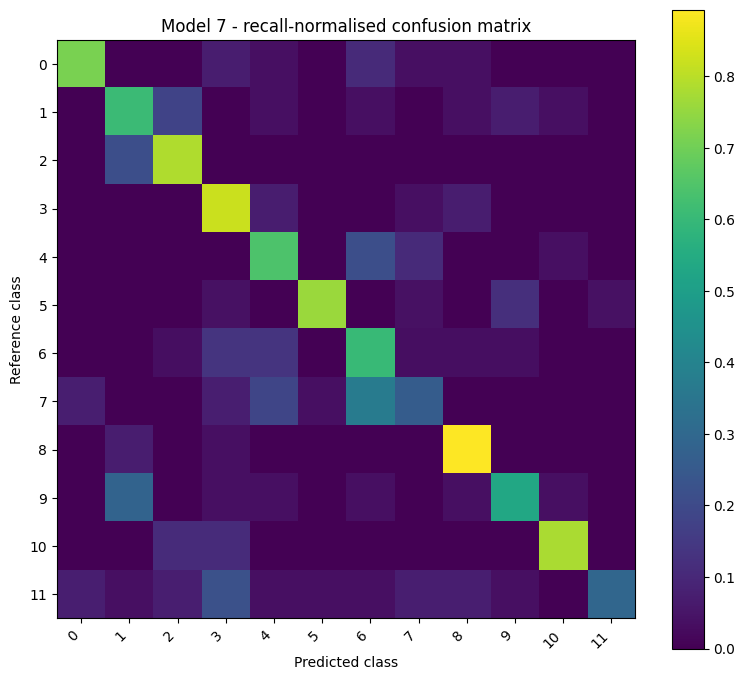

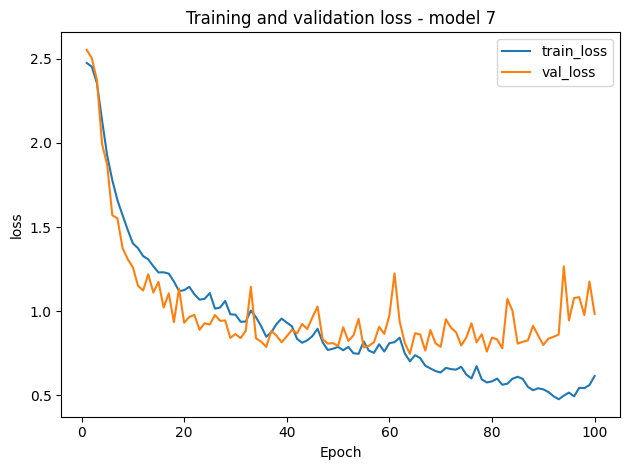


Training model 8
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_28 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_28 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_29 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_29 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_30 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_30 (MaxPoolin  (None,

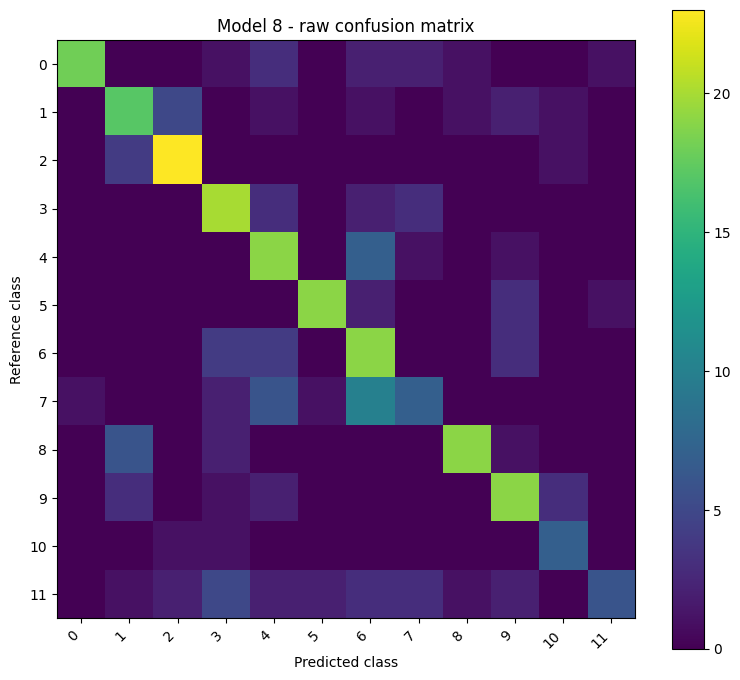

Class-wise precision: [0.94736842 0.5483871  0.74193548 0.55555556 0.475      0.86363636
 0.41304348 0.4375     0.86363636 0.61290323 0.58333333 0.75      ]


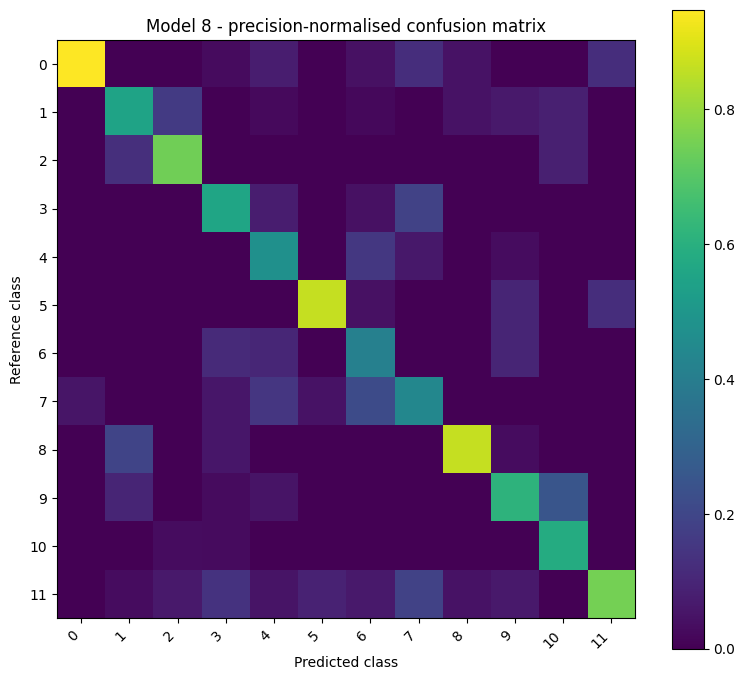

Class-wise recall: [0.64285714 0.60714286 0.82142857 0.71428571 0.67857143 0.76
 0.63333333 0.25925926 0.67857143 0.67857143 0.77777778 0.22222222]


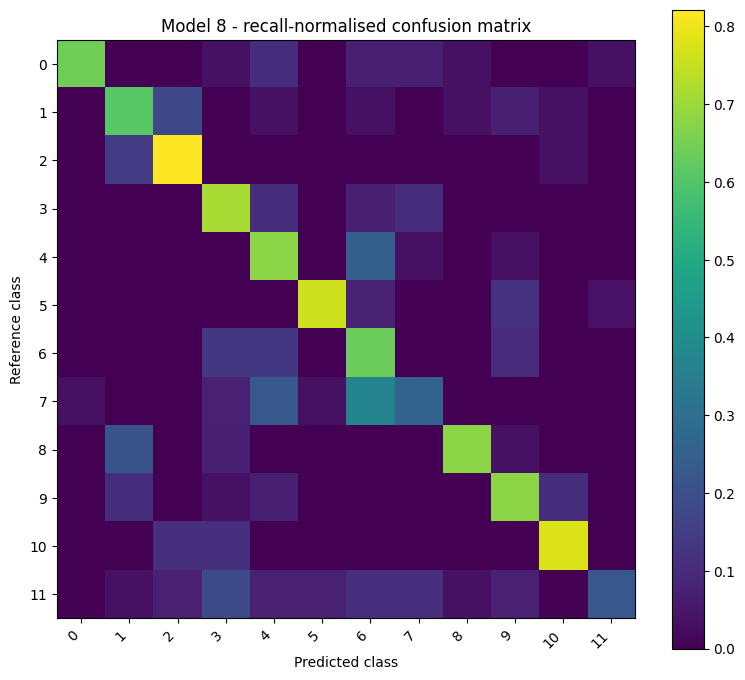

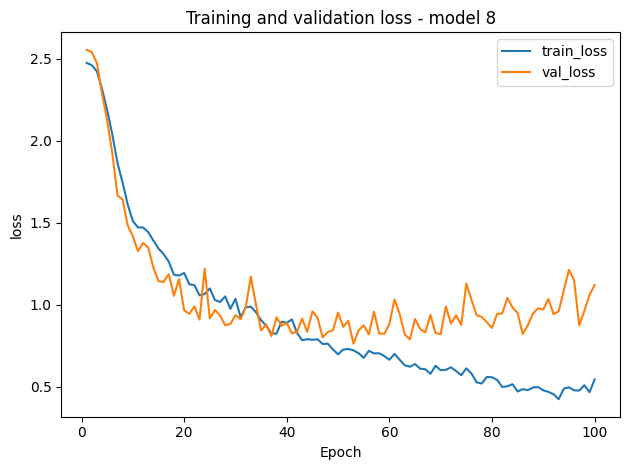


Training model 9
Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_32 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_32 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_33 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_33 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_34 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_34 (MaxPoolin  (None,

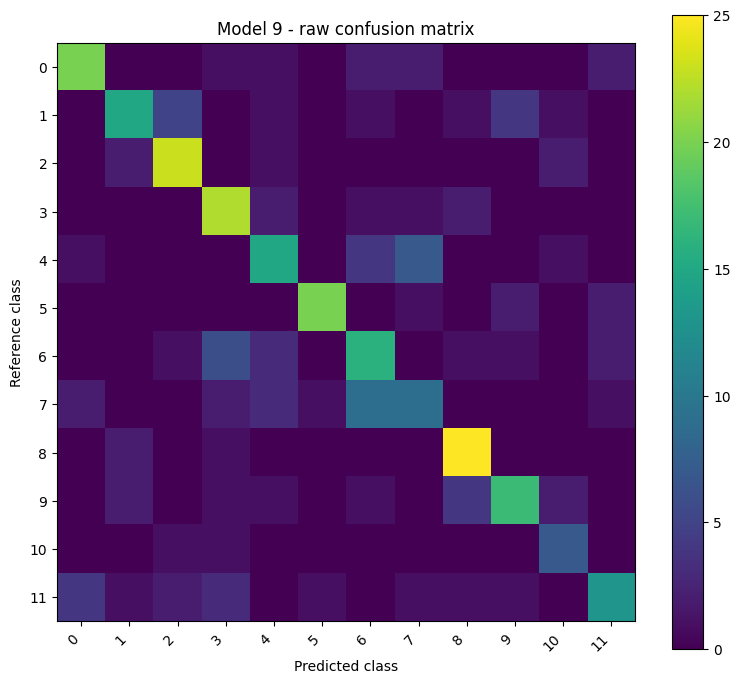

Class-wise precision: [0.74074074 0.68181818 0.71875    0.59459459 0.55555556 0.90909091
 0.47058824 0.42857143 0.73529412 0.68       0.53846154 0.65      ]


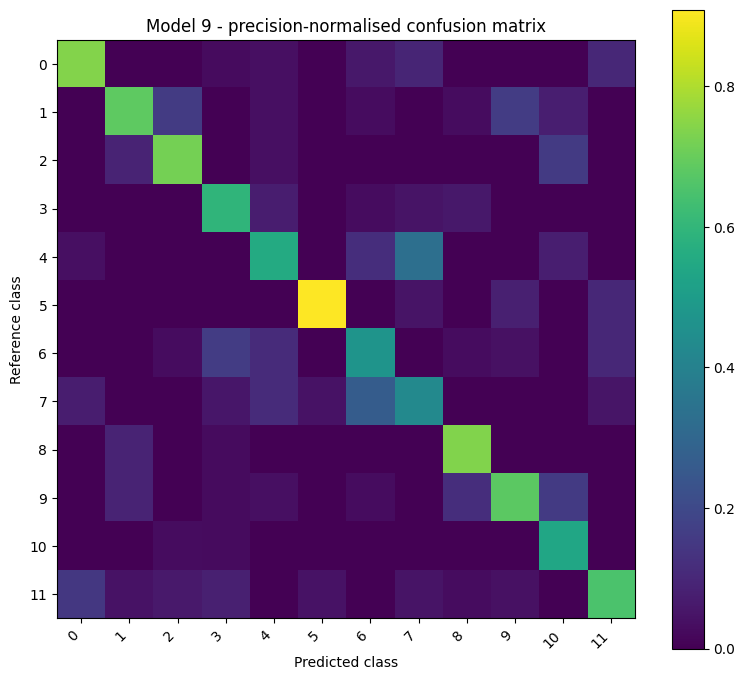

Class-wise recall: [0.71428571 0.53571429 0.82142857 0.78571429 0.53571429 0.8
 0.53333333 0.33333333 0.89285714 0.60714286 0.77777778 0.48148148]


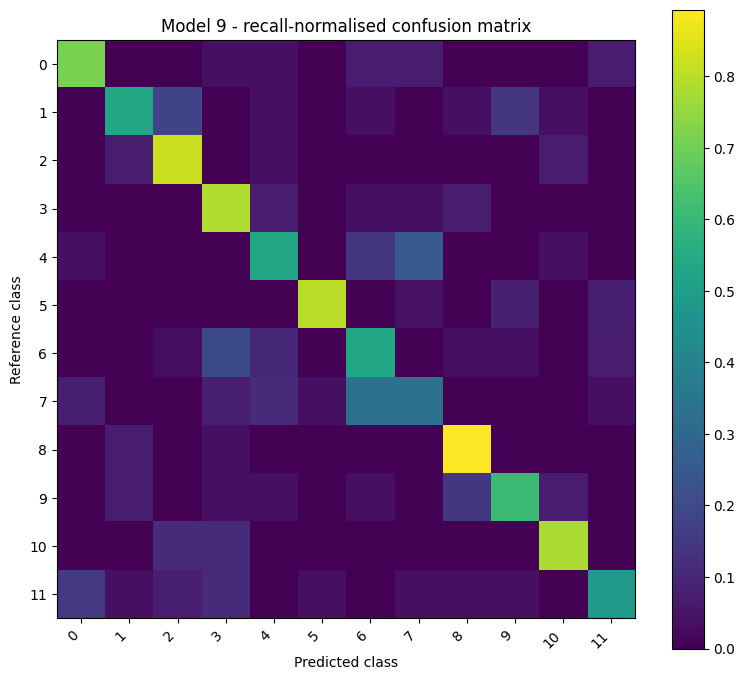

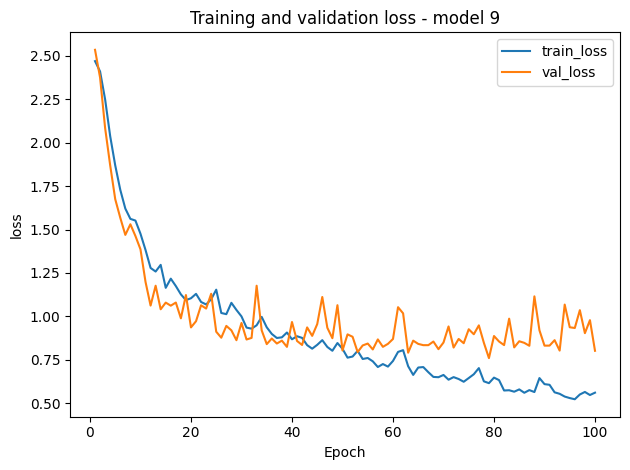


Training model 10
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_36 (Conv2D)          (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_36 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_37 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_37 (MaxPoolin  (None, 14, 14, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_38 (Conv2D)          (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_38 (MaxPoolin  (None

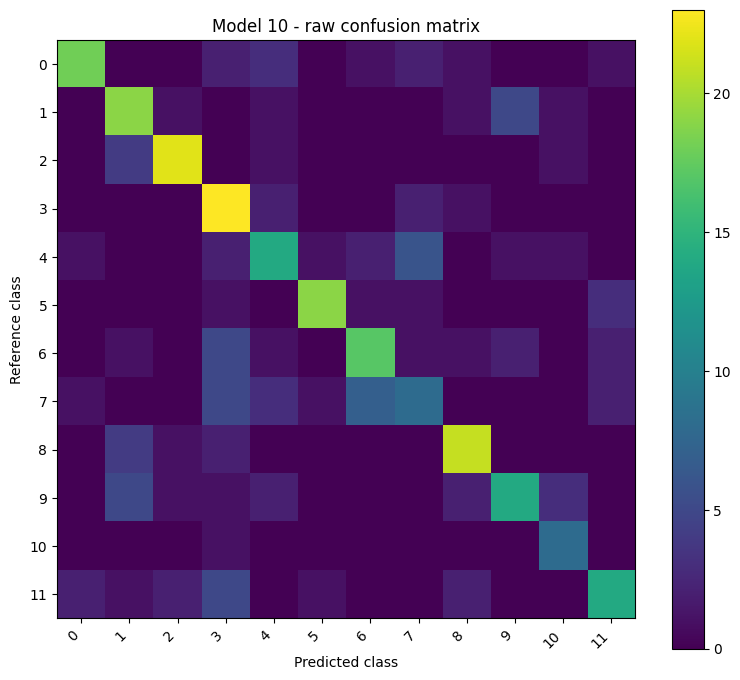

Class-wise precision: [0.81818182 0.55882353 0.81481481 0.4893617  0.51851852 0.86363636
 0.60714286 0.4        0.72413793 0.63636364 0.57142857 0.63636364]


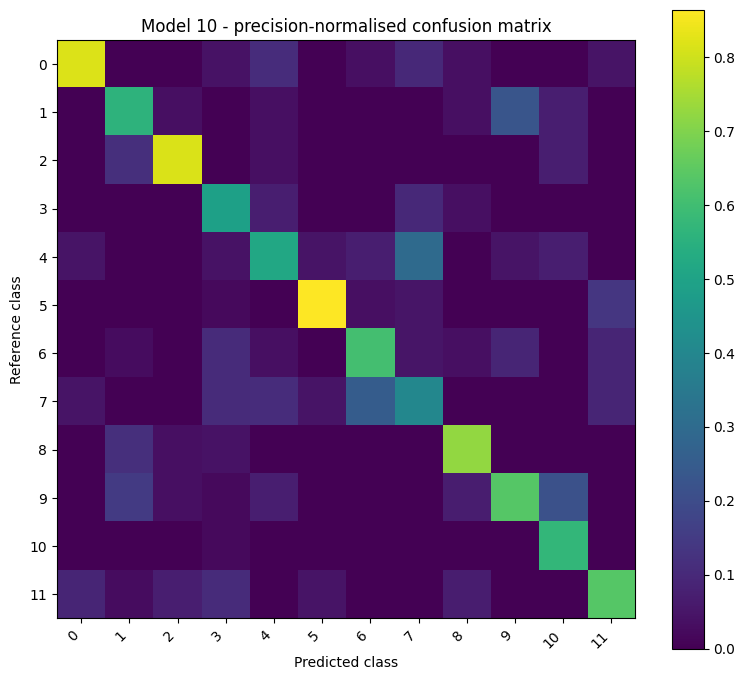

Class-wise recall: [0.64285714 0.67857143 0.78571429 0.82142857 0.5        0.76
 0.56666667 0.2962963  0.75       0.5        0.88888889 0.51851852]


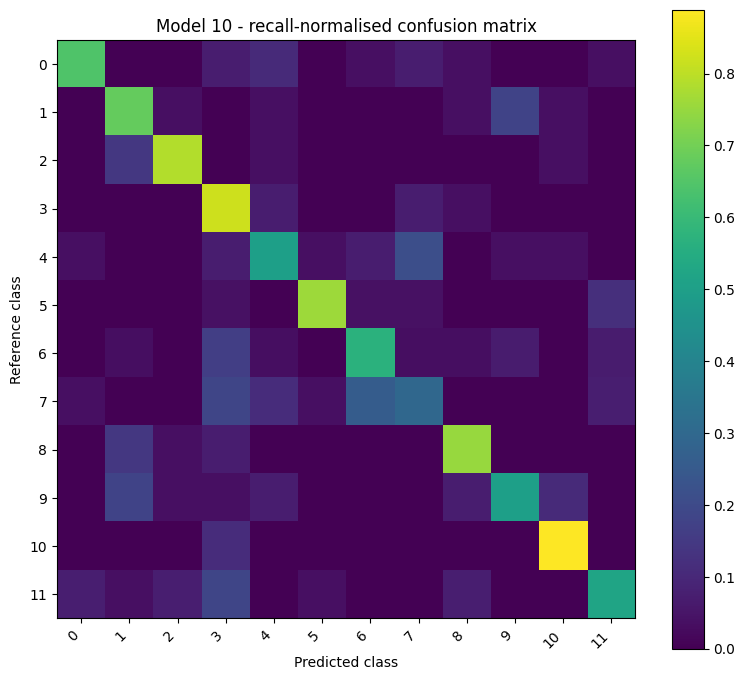

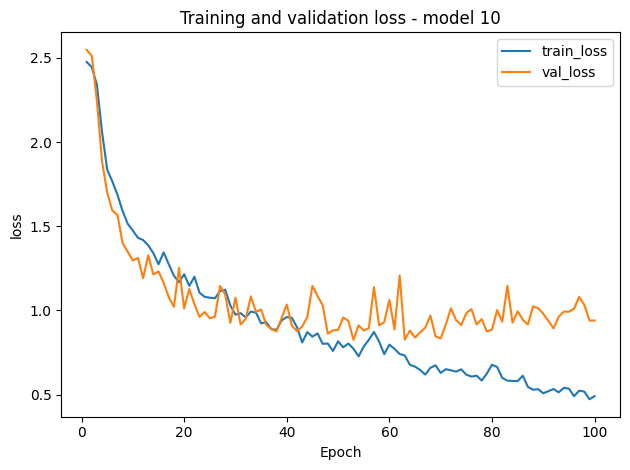

In [8]:
predictions_list, models, histories = train_ensemble(
    n_models=cfg.N_MODELS,
    x_train=X_train,
    x_test=X_test,
    y_train=y_train,
    y_test=y_test,
    y_test_raw=y_test_raw,
    input_shape=cfg.INPUT_SHAPE,
    n_classes=cfg.N_CLASSES,
    batch_size=cfg.BATCH_SIZE,
    epochs=cfg.EPOCHS,
    validation_split=cfg.VALIDATION_SPLIT,
    figures_dir=cfg.FIGURES_DIR,
    loss=training_loss,
    class_names=[str(i) for i in range(cfg.N_CLASSES)],
)

## 9. Ensemble prediction and evaluation

Overall accuracy: 0.6560509554140127
Weighted precision: 0.6576825841182894
Weighted recall: 0.6560509554140127
Weighted F1 score: 0.6514243103801042

Per-class classification report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.64      0.64      0.64        28
           2       0.77      0.86      0.81        28
           3       0.58      0.79      0.67        28
           4       0.52      0.57      0.54        28
           5       0.83      0.80      0.82        25
           6       0.59      0.63      0.61        30
           7       0.35      0.26      0.30        27
           8       0.77      0.82      0.79        28
           9       0.72      0.64      0.68        28
          10       0.54      0.78      0.64         9
          11       0.68      0.48      0.57        27

    accuracy                           0.66       314
   macro avg       0.65      0.66      0.65       314
weig

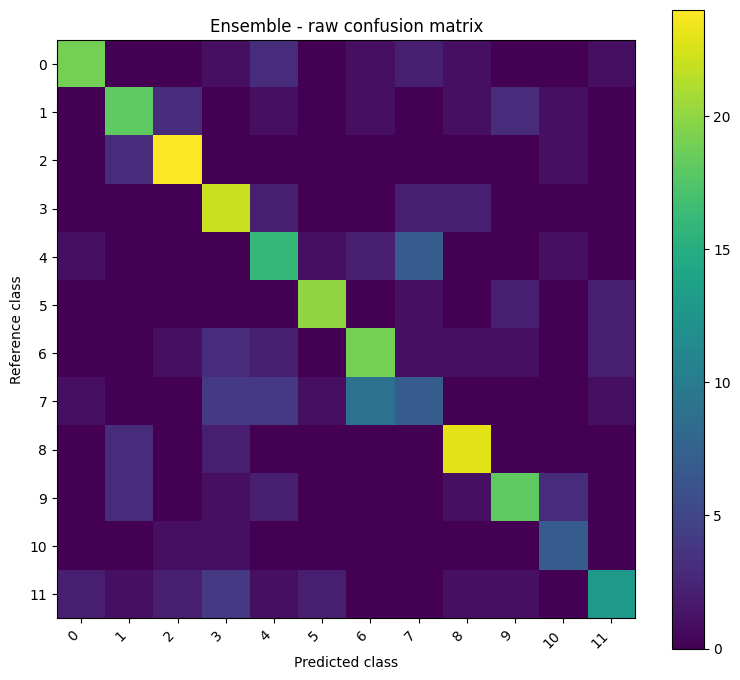

Class-wise precision: [0.82608696 0.64285714 0.77419355 0.57894737 0.51612903 0.83333333
 0.59375    0.35       0.76666667 0.72       0.53846154 0.68421053]


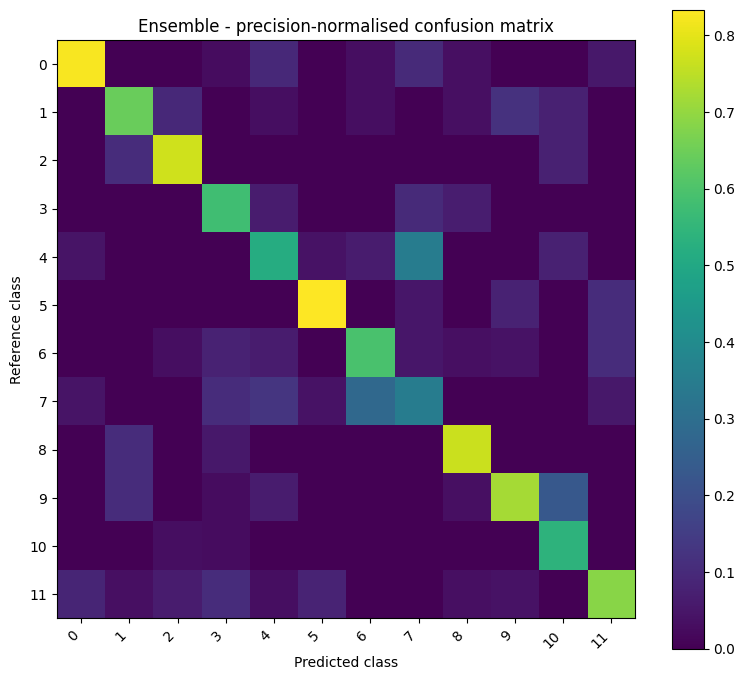

Class-wise recall: [0.67857143 0.64285714 0.85714286 0.78571429 0.57142857 0.8
 0.63333333 0.25925926 0.82142857 0.64285714 0.77777778 0.48148148]


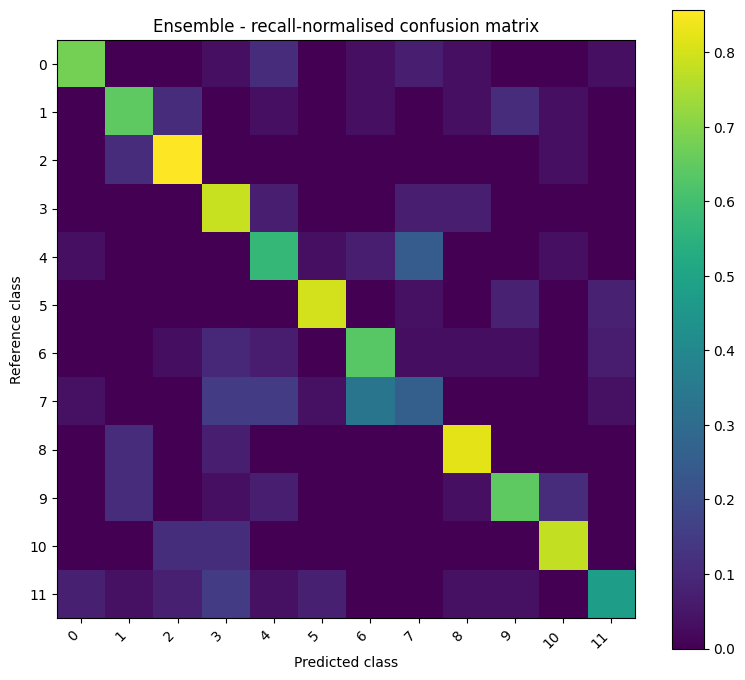

In [9]:
ensemble_predictions = average_ensemble_probabilities(predictions_list)
ensemble_labels = np.argmax(ensemble_predictions, axis=1)

ensemble_evaluation = evaluate_predictions(
    y_test_raw,
    ensemble_labels,
    cfg.FIGURES_DIR,
    file_stem="ensemble",
    title_prefix="Ensemble",
    class_names=[str(i) for i in range(cfg.N_CLASSES)],
)

## 10. Probability quality and ROC curves

Brier score for class 0: 0.0277
Brier score for class 1: 0.0467
Brier score for class 2: 0.0270
Brier score for class 3: 0.0456
Brier score for class 4: 0.0517
Brier score for class 5: 0.0210
Brier score for class 6: 0.0550
Brier score for class 7: 0.0651
Brier score for class 8: 0.0239
Brier score for class 9: 0.0392
Brier score for class 10: 0.0160
Brier score for class 11: 0.0504


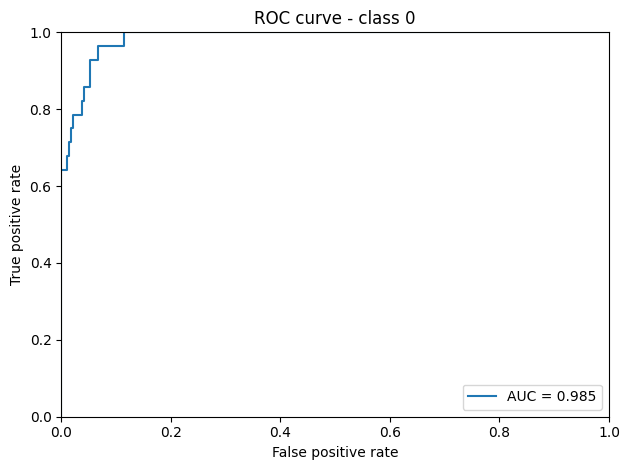

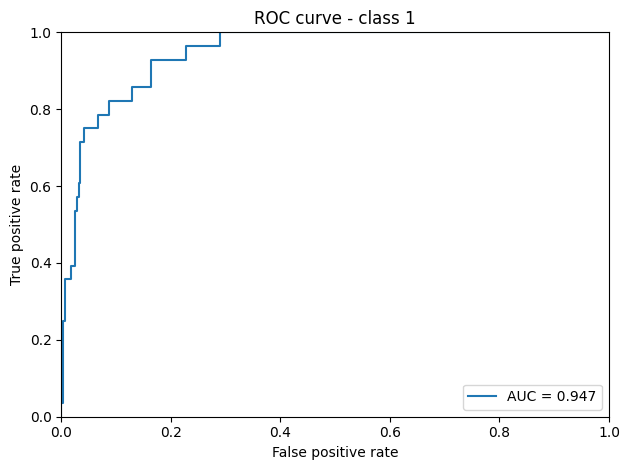

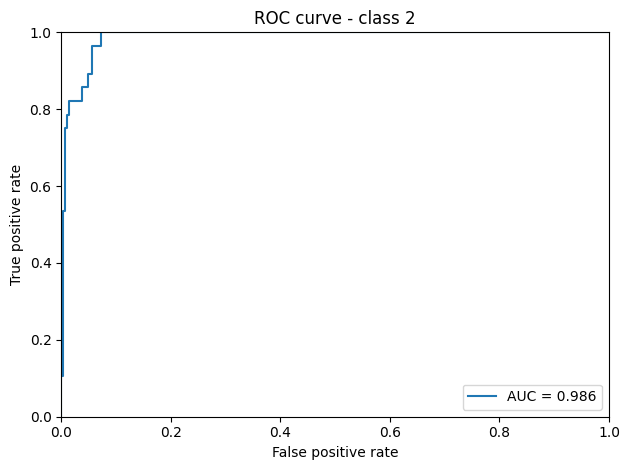

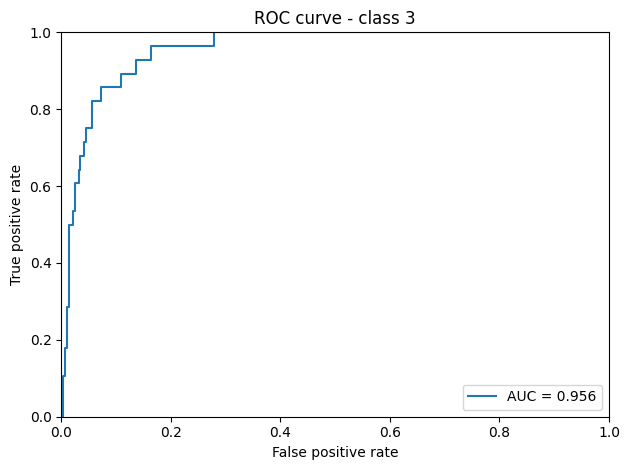

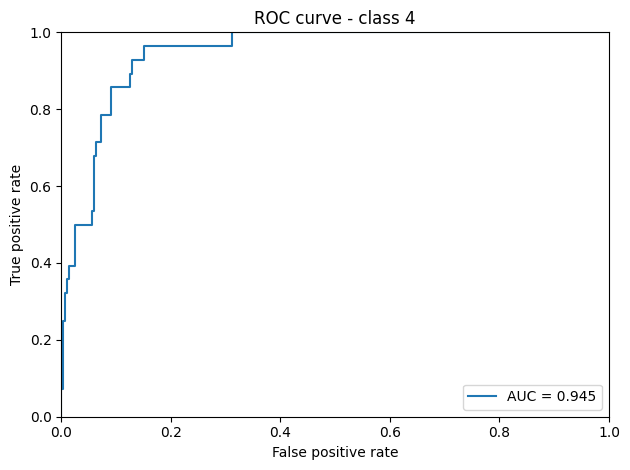

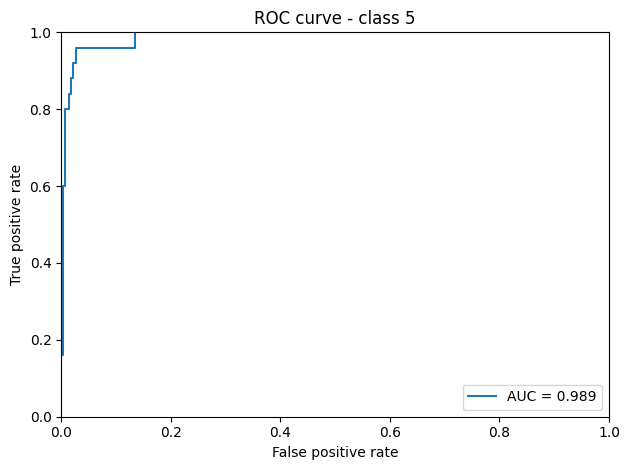

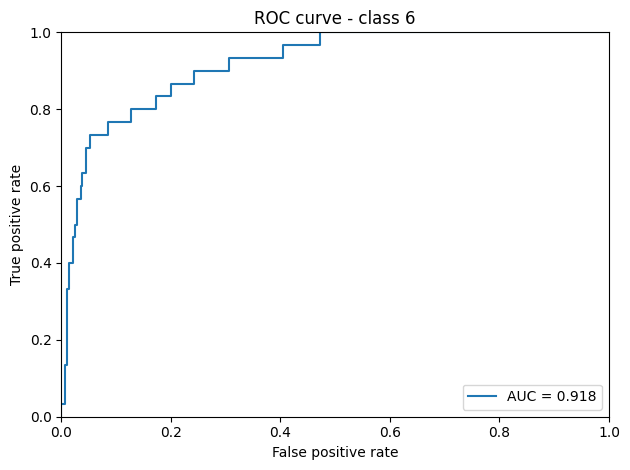

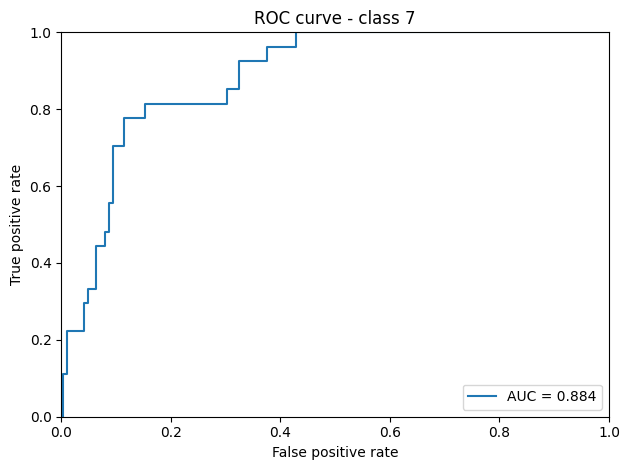

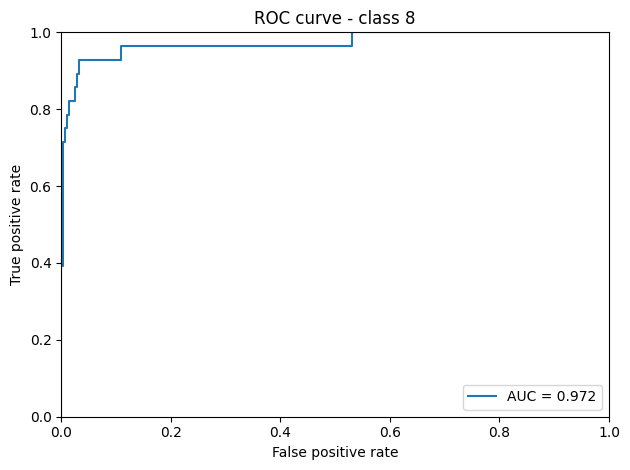

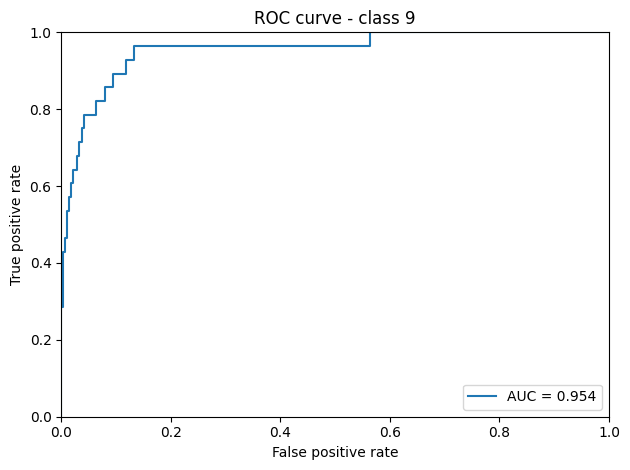

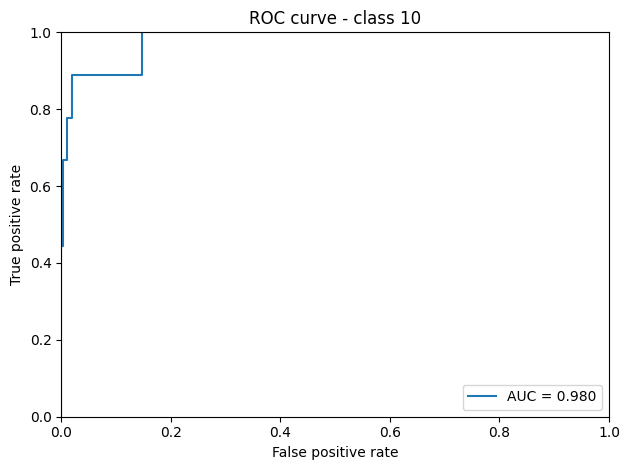

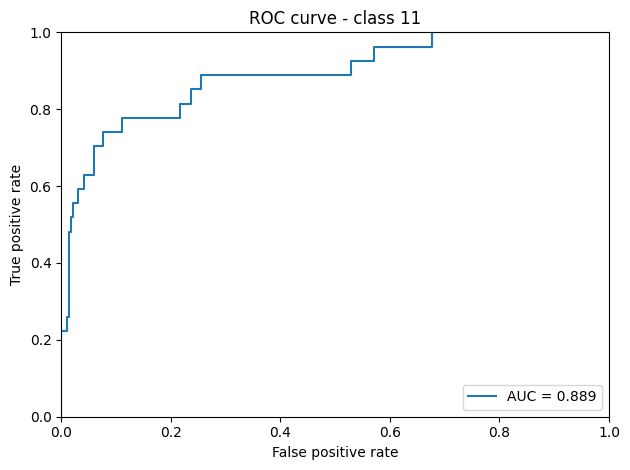

In [10]:
brier_scores = compute_brier_scores(y_test_raw, ensemble_predictions, cfg.N_CLASSES)
plot_roc_curves(y_test_raw, ensemble_predictions, cfg.N_CLASSES, cfg.FIGURES_DIR)

## 11. Save trained models

In [11]:
save_models(models, cfg.MODELS_DIR)

Saved 10 models to X:\Projets\CASMATTELEv2\Stage_Hugo\py\classification\DL\DL_3_github\models


## 12. Optional MobileNetV2 ImageNet transfer-learning test

This additional experiment addresses the reviewer request by testing a model pre-trained on ImageNet. The original 64 × 64 patches are kept unchanged in the dataset; resizing to 224 × 224 is performed inside the model. The MobileNetV2 backbone is frozen by default, so the comparison evaluates whether generic ImageNet visual features transfer to the rooftop material classification task.

## 13. Runtime

In [12]:
end_time = time.perf_counter()
print(f"Duration: {end_time - start_time:.4f} seconds")

Duration: 1872.0715 seconds
